In [1]:
# ==========================================
# Importok és Adatbetöltés
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import shap  # pip install shap

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.pipeline import Pipeline

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Betöltés
df = pd.read_csv('processed_credit_data.csv')
print(f"Adatok betöltve: {df.shape}")

Adatok betöltve: (17356, 61)


In [2]:
# ==========================================
# Encoding és Split
# ==========================================
# Kategorikus változók átalakítása (Label Encoding)
# Az XGBoost kezeli a kategóriákat, de a LabelEncoding a legbiztosabb módszer.

cat_cols = df.select_dtypes(include=['object']).columns.tolist()
if 'loan_grade' in cat_cols: cat_cols.remove('loan_grade')

print(f"Encoding categorical columns: {cat_cols}")

label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# Target Encoding
target_le = LabelEncoder()
df['loan_grade'] = target_le.fit_transform(df['loan_grade'])
target_names = target_le.classes_

# Adatbázis szétválasztása
# FONTOS: Az 'is_biased_opinion'-t itt eldobjuk az X-ből, mert ez "csalás" lenne (target leakage),
# de elmentjük egy külön változóba, hogy később elemezzük a bias hatását!
X = df.drop(columns=['loan_grade', 'is_biased_opinion'])
y = df['loan_grade']
bias_flag = df['is_biased_opinion'] # Későbbi analízishez

# Stratified Split (hogy minden osztályból arányosan kerüljön a tesztbe)
X_train, X_test, y_train, y_test, bias_train, bias_test = train_test_split(
    X, y, bias_flag, test_size=0.2, random_state=42, stratify=y
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Encoding categorical columns: ['loan_purpose', 'legal_entity_type', 'property', 'Industry_code', 'pl_subseg_desc', 'address_county']
Train shape: (13884, 59), Test shape: (3472, 59)


In [4]:
# ==========================================
# XGBoost Hyperparameter Tuning (RandomizedSearch)
# ==========================================
# Nem sima .fit()-et használunk, hanem keresünk jobb paramétereket.

# Paraméter rács
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 6, 8, 10],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.5, 1]
}

clf_xgb = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=len(target_names),
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)

# Keresés
print("Hyperparameter tuning indítása (RandomizedSearchCV)...")
random_search = RandomizedSearchCV(
    clf_xgb,
    param_distributions=param_dist,
    n_iter=10, # Hány kombinációt próbáljon ki
    scoring='accuracy',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print(f"Legjobb paraméterek: {random_search.best_params_}")
best_model = random_search.best_estimator_

Hyperparameter tuning indítása (RandomizedSearchCV)...
Fitting 3 folds for each of 10 candidates, totalling 30 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:27:49] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Legjobb paraméterek: {'subsample': 0.7, 'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.1, 'gamma': 0.5, 'colsample_bytree': 0.7}



--- Classification Report ---
              precision    recall  f1-score   support

           A       0.98      0.97      0.97       516
           B       0.98      0.99      0.99      1035
           C       1.00      1.00      1.00      1042
           D       0.96      0.96      0.96       531
           E       0.94      0.94      0.94       348

    accuracy                           0.98      3472
   macro avg       0.97      0.97      0.97      3472
weighted avg       0.98      0.98      0.98      3472



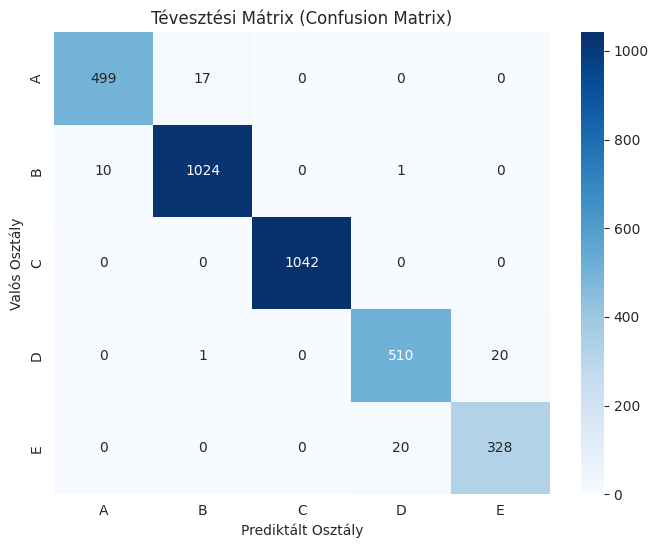

In [5]:
# ==========================================
# Modell Kiértékelés
# ==========================================
y_pred = best_model.predict(X_test)

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=target_names))

# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.ylabel('Valós Osztály')
plt.xlabel('Prediktált Osztály')
plt.title('Tévesztési Mátrix (Confusion Matrix)')
plt.show()

/tmp/ipykernel_7401/2625666066.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_imp.head(20), y=feature_imp.head(20).index, palette='viridis')


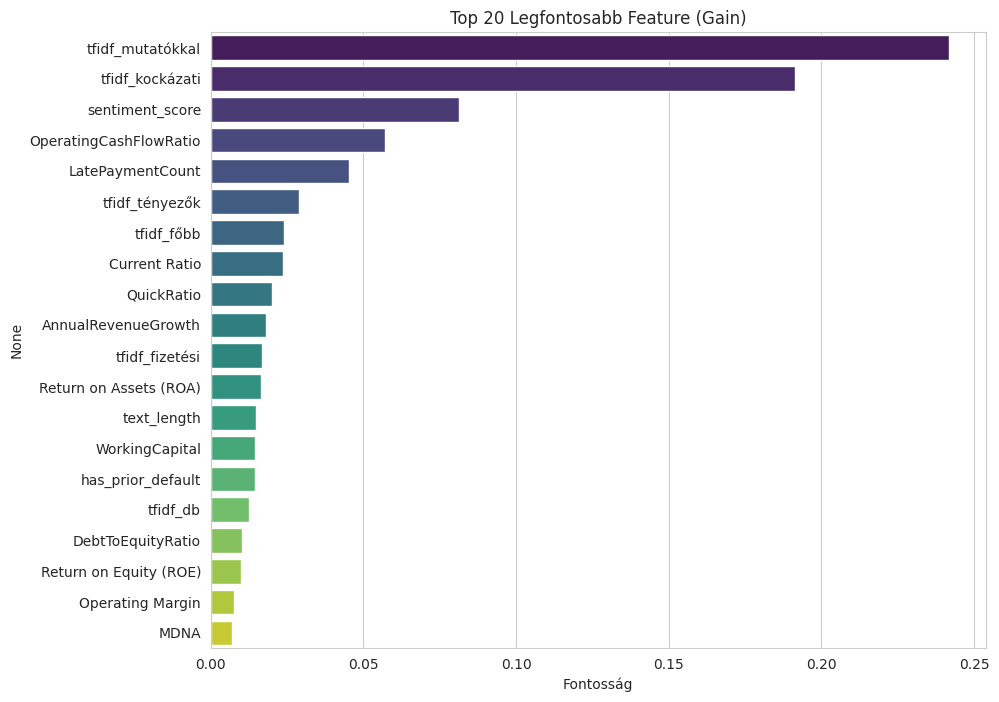


NLP Feature-ök fontossága:
tfidf_mutatókkal          0.241760
tfidf_kockázati           0.191399
sentiment_score           0.081433
tfidf_tényezők            0.028932
tfidf_főbb                0.024013
tfidf_fizetési            0.016928
tfidf_db                  0.012465
tfidf_jelen               0.006401
tfidf_egy                 0.006209
tfidf_hitelcél            0.005583
tfidf_fedezet             0.005297
tfidf_késedelem           0.005282
tfidf_fő                  0.004432
tfidf_ingatlan            0.004374
tfidf_kft                 0.003806
tfidf_érték               0.003726
tfidf_ügyfél              0.003657
tfidf_huf                 0.003148
tfidf_szektorban          0.002946
tfidf_mikrovállalkozás    0.002594
tfidf_tevékenysége        0.002287
dtype: float32


In [6]:
# ==========================================
# Feature Importance (Hagyományos)
# ==========================================
feature_imp = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=feature_imp.head(20), y=feature_imp.head(20).index, palette='viridis')
plt.title('Top 20 Legfontosabb Feature (Gain)')
plt.xlabel('Fontosság')
plt.show()

# Nézzük meg, hol végeztek az NLP feature-ök
nlp_features = [col for col in X.columns if 'sentiment' in col or 'tfidf' in col]
print("\nNLP Feature-ök fontossága:")
print(feature_imp[feature_imp.index.isin(nlp_features)])

SHAP értékek számítása...


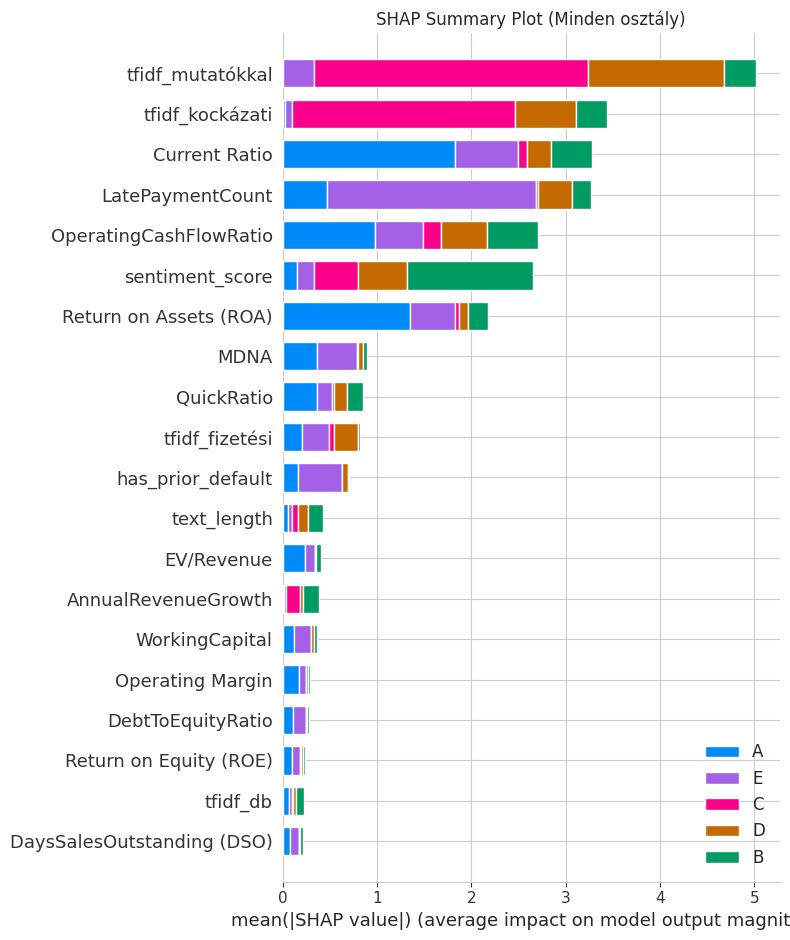

SHAP elemzés a 'D' osztályhoz:


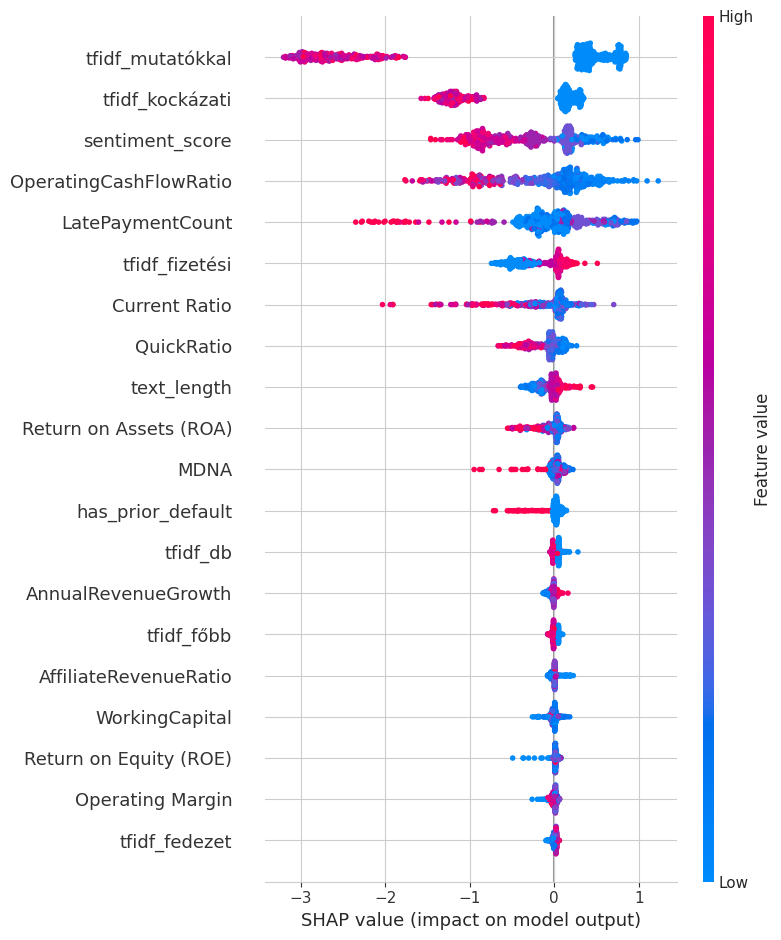

In [11]:
# ==========================================
# SHAP Elemzés
# ==========================================
# A SHAP megmutatja, HOGYAN befolyásolták az egyes értékek a döntést.

print("SHAP értékek számítása...")
explainer = shap.TreeExplainer(best_model)
# Csak egy mintán futtatjuk a sebesség miatt (pl. 500 sor)
X_test_sample = X_test.iloc[:500]
shap_values = explainer.shap_values(X_test_sample)

# Summary Plot (Minden osztályra)
# Ez megmutatja, melyik változó húzza szét legjobban a kategóriákat
plt.title("SHAP Summary Plot (Minden osztály)")
shap.summary_plot(shap_values, X_test_sample, plot_type="bar", class_names=target_names)

# Részletes Summary Plot csak a 'D' (kockázatos) kategóriára (index 3)
# Megnézzük, miért sorol be valakit a modell 'D'-be.
class_index = 3 # D osztály (feltételezve A=0, B=1, C=2, D=3, E=4)
print(f"SHAP elemzés a '{target_names[class_index]}' osztályhoz:")
shap.summary_plot(shap_values[:, :, class_index], X_test_sample)

In [12]:
# ==========================================
# Bias Elemzés (Torzítás hatása)
# ==========================================
# Itt vizsgáljuk meg, hogy az elfogult szövegek átverték-e a modellt.

# Készítünk egy DataFrame-et a teszt eredményekkel
results_df = X_test.copy()
results_df['True_Grade'] = y_test
results_df['Pred_Grade'] = y_pred
results_df['Is_Biased'] = bias_test

# Leszűrjük a "Rossz" adósokat (D és E - azaz 3 és 4 index)
bad_debtors = results_df[results_df['True_Grade'].isin([3, 4])]

# Mennyi a modell pontossága a "Tiszta" rossz adósokon vs. a "Torzított" rossz adósokon?
acc_clean = accuracy_score(bad_debtors[bad_debtors['Is_Biased']==0]['True_Grade'],
                           bad_debtors[bad_debtors['Is_Biased']==0]['Pred_Grade'])

acc_biased = accuracy_score(bad_debtors[bad_debtors['Is_Biased']==1]['True_Grade'],
                            bad_debtors[bad_debtors['Is_Biased']==1]['Pred_Grade'])

print("\n--- BIAS HATÁS EREDMÉNYE ---")
print(f"Modell pontossága a VALÓS leírású rossz adósokon: {acc_clean:.2%}")
print(f"Modell pontossága a TORZÍTOTT (szépített) leírású rossz adósokon: {acc_biased:.2%}")

if acc_biased < acc_clean:
    print("KÖVETKEZTETÉS: A modell teljesítménye romlott a torzított adatokon. A pozitív szövegek részben 'megtévesztették' a modellt.")
else:
    print("KÖVETKEZTETÉS: A modell robusztus maradt, a pénzügyi adatok domináltak a szöveggel szemben.")


--- BIAS HATÁS EREDMÉNYE ---
Modell pontossága a VALÓS leírású rossz adósokon: 95.74%
Modell pontossága a TORZÍTOTT (szépített) leírású rossz adósokon: 89.66%
KÖVETKEZTETÉS: A modell teljesítménye romlott a torzított adatokon. A pozitív szövegek részben 'megtévesztették' a modellt.
